In [3]:
# Import all necessary libraries for data processing, modeling, and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully!
Pandas version: 3.0.3
NumPy version: 2.5.1


In [4]:
# Load the training and test datasets from the dataset folder
# train.csv contains labeled data with target variable 'Y'
# test.csv contains unlabeled data for which we need to make predictions
train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')

# Display basic information about the datasets
print("="*80)
print("DATASET OVERVIEW")
print("="*80)
print(f"\nTraining set shape: {train_df.shape} (rows, columns)")
print(f"Test set shape: {test_df.shape} (rows, columns)")

# Display first few rows to understand the data structure
print("\nFirst 5 rows of training data:")
display(train_df.head())

# Display basic information about data types and memory usage
print("\nTraining data info:")
print(train_df.info())

# Check for missing values in training data
print("\nMissing values in training data:")
print(train_df.isnull().sum().sort_values(ascending=False))

DATASET OVERVIEW

Training set shape: (1352, 51) (rows, columns)
Test set shape: (339, 50) (rows, columns)

First 5 rows of training data:


,CoilID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,Y
0,487,854.787195,501.088868,414.841484,710.583316,662.072013,656.076977,547.040479,563.653582,495.296785,...,0.201645,0.047960,0.267467,0.052247,-0.893174,0.000000,0.028925,0.000534,0.010797,0.0
1,44,1056.526699,868.083321,622.879982,725.276469,665.235554,647.450550,552.333202,565.105074,493.310075,...,0.644403,0.000000,0.341870,0.153513,25.471899,0.002520,0.033281,0.028349,0.079602,0.0
2,192,1095.648362,668.112517,695.787904,716.773671,662.843475,657.542380,549.863867,546.210823,482.814753,...,0.486502,0.000000,0.202539,0.168192,-25.764196,0.002072,0.033878,0.000000,0.058266,0.0
3,1552,1050.943543,660.340015,440.280245,611.562496,628.081103,561.397721,456.816210,550.103433,378.353283,...,1.198010,0.020787,0.288786,0.329108,1.033840,0.000250,0.045490,0.039004,0.004850,0.0
4,1190,1091.640314,297.363775,842.665620,749.160886,652.992309,615.576656,608.364764,549.756758,487.753140,...,0.237231,0.000841,0.257281,0.112637,-11.130157,0.002376,0.031298,0.003623,0.018434,0.0



Training data info:
<class 'pandas.DataFrame'>
RangeIndex: 1352 entries, 0 to 1351
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CoilID  1352 non-null   int64  
 1   X1      1352 non-null   float64
 2   X2      1352 non-null   float64
 3   X3      1352 non-null   float64
 4   X4      1352 non-null   float64
 5   X5      1352 non-null   float64
 6   X6      1352 non-null   float64
 7   X7      1352 non-null   float64
 8   X8      1351 non-null   float64
 9   X9      1352 non-null   float64
 10  X10     1346 non-null   float64
 11  X11     1352 non-null   float64
 12  X12     1352 non-null   float64
 13  X13     1352 non-null   float64
 14  X14     1352 non-null   float64
 15  X15     1192 non-null   float64
 16  X16     1346 non-null   float64
 17  X17     1352 non-null   float64
 18  X18     1352 non-null   float64
 19  X19     1352 non-null   float64
 20  X20     1352 non-null   float64
 21  X21     1351 non-null   flo

TARGET VARIABLE ANALYSIS

Target distribution:
Y
0.0    1286
1.0      66
Name: count, dtype: int64

Percentage of defects: 4.88%
Imbalance ratio (0:1): 19.48:1


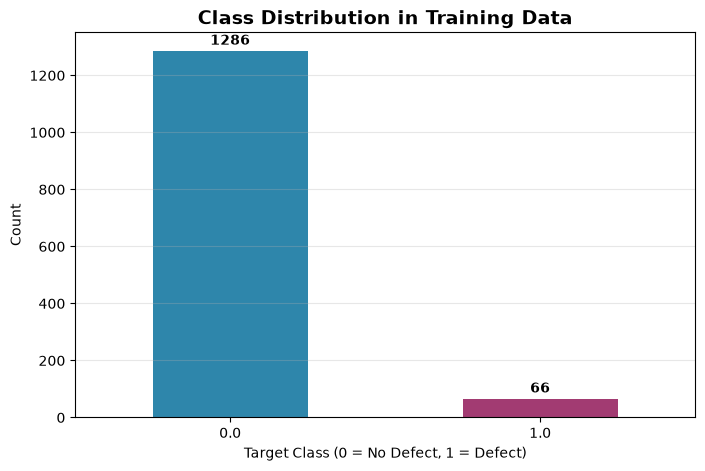


STATISTICAL SUMMARY OF FEATURES

Statistical summary of features:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X40,X41,X42,X43,X44,X45,X46,X47,X48,X49
count,1352.000000,1352.000000,1352.000000,1352.000000,1352.000000,1352.000000,1352.000000,1351.000000,1352.000000,1346.000000,...,1352.000000,1352.000000,1321.000000,1352.000000,1352.000000,1352.000000,1352.000000,1352.000000,1339.000000,1352.000000
mean,1028.915322,575.374555,538.372787,692.576938,649.010832,618.584573,529.241056,528.770054,461.699867,6.869788,...,61.877959,0.585886,0.011334,0.281290,0.091495,11.507361,0.002745,0.050913,0.007108,0.064400
std,108.505011,232.103882,135.288085,56.798904,35.398207,45.602831,46.263179,40.220201,40.600916,2.632747,...,3.838222,0.296115,0.017114,0.068455,0.073058,25.004864,0.006660,0.044617,0.012504,0.050905
min,235.252250,96.755492,124.150450,575.916250,559.272859,529.937396,439.221384,425.413251,343.110465,1.117275,...,56.000000,0.077352,0.000000,0.029599,0.000000,-82.672877,0.000000,0.016833,0.000000,0.000000
25%,1009.279089,405.533242,441.585514,622.213663,625.327743,583.363796,476.813303,520.192858,423.604248,4.704389,...,58.000000,0.365881,0.000380,0.244377,0.026073,-1.368777,0.000943,0.039864,0.000000,0.015624
50%,1071.978233,589.160841,548.035306,724.970407,661.170690,615.240491,547.648095,545.399528,482.412285,7.001339,...,62.000000,0.574328,0.002613,0.293164,0.076108,9.177752,0.001644,0.045829,0.001056,0.060336
75%,1092.031100,725.766924,632.238363,734.453213,668.054192,659.564239,554.584166,556.334294,488.713960,8.968052,...,62.000000,0.797025,0.013933,0.334613,0.143156,24.196605,0.002275,0.051435,0.002679,0.106017
max,1124.903234,1148.171484,1026.915778,755.983296,763.257466,742.725523,618.947910,575.312130,505.349388,12.312371,...,72.000000,1.377925,0.062637,0.409739,0.329108,120.169658,0.064545,0.424405,0.051150,0.249522



Checking for constant features (zero variance):
No constant features found - all features have variation


In [5]:
# Analyze the target variable distribution and get statistical summary of features

print("="*80)
print("TARGET VARIABLE ANALYSIS")
print("="*80)

# Check target variable distribution (0 = No Defect, 1 = Defect)
print("\nTarget distribution:")
print(train_df['Y'].value_counts())
print(f"\nPercentage of defects: {train_df['Y'].mean() * 100:.2f}%")
print(f"Imbalance ratio (0:1): {train_df['Y'].value_counts()[0] / train_df['Y'].value_counts()[1]:.2f}:1")

# Visualize the class distribution
plt.figure(figsize=(8, 5))
colors = ['#2E86AB', '#A23B72']
train_df['Y'].value_counts().plot(kind='bar', color=colors)
plt.title('Class Distribution in Training Data', fontsize=14, fontweight='bold')
plt.xlabel('Target Class (0 = No Defect, 1 = Defect)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(train_df['Y'].value_counts().values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.show()

print("\n" + "="*80)
print("STATISTICAL SUMMARY OF FEATURES")
print("="*80)

# Get statistical summary of all feature columns (excluding CoilID and Y)
feature_cols = [col for col in train_df.columns if col not in ['CoilID', 'Y']]
print("\nStatistical summary of features:")
display(train_df[feature_cols].describe())

# Check for any extreme outliers or unusual values
print("\nChecking for constant features (zero variance):")
constant_features = []
for col in feature_cols:
    if train_df[col].nunique() <= 1:
        constant_features.append(col)
        
if len(constant_features) > 0:
    print(f"Found {len(constant_features)} constant features: {constant_features}")
else:
    print("No constant features found - all features have variation")

In [6]:
# Handle missing values appropriately for industrial data
# Using median imputation because it's robust to outliers

print("="*80)
print("DATA PREPROCESSING - MISSING VALUES")
print("="*80)

# Separate features and target from training data
# CoilID is just an identifier, not a predictive feature
X_train = train_df.drop(['CoilID', 'Y'], axis=1)
y_train = train_df['Y']
X_test = test_df.drop(['CoilID'], axis=1)
coil_ids = test_df['CoilID']

print(f"Features shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Target shape: {y_train.shape}")

# Check missing values count before imputation
print("\nMissing values before imputation:")
print(f"Training set: {X_train.isnull().sum().sum()} missing values")
print(f"Test set: {X_test.isnull().sum().sum()} missing values")

# Identify columns with missing values
missing_cols_train = X_train.columns[X_train.isnull().any()].tolist()
missing_cols_test = X_test.columns[X_test.isnull().any()].tolist()

print(f"\nColumns with missing values in train: {missing_cols_train}")
print(f"Columns with missing values in test: {missing_cols_test}")

# Impute missing values using median from training data
# Median is preferred over mean for industrial data to handle outliers
print("\nImputing missing values with median...")

# Calculate medians from training data
medians = X_train.median()

# Fill missing values in training set
X_train_filled = X_train.fillna(medians)

# Fill missing values in test set using training medians
X_test_filled = X_test.fillna(medians)

print(f"\nMissing values after imputation:")
print(f"Training set: {X_train_filled.isnull().sum().sum()} missing values")
print(f"Test set: {X_test_filled.isnull().sum().sum()} missing values")

# Verify that all missing values are handled
assert X_train_filled.isnull().sum().sum() == 0, "Training set still has missing values!"
assert X_test_filled.isnull().sum().sum() == 0, "Test set still has missing values!"

print("\n✓ Missing values successfully handled!")

DATA PREPROCESSING - MISSING VALUES
Features shape: (1352, 49)
Test shape: (339, 49)
Target shape: (1352,)

Missing values before imputation:
Training set: 249 missing values
Test set: 68 missing values

Columns with missing values in train: ['X8', 'X10', 'X15', 'X16', 'X21', 'X23', 'X24', 'X25', 'X26', 'X27', 'X42', 'X48']
Columns with missing values in test: ['X15', 'X42', 'X48']

Imputing missing values with median...

Missing values after imputation:
Training set: 0 missing values
Test set: 0 missing values

✓ Missing values successfully handled!


EXPLORATORY DATA ANALYSIS - FEATURE CORRELATIONS

Top 10 features most positively correlated with defects:
X13    0.252931
X10    0.237659
X30    0.218508
X31    0.212220
X32    0.210746
X29    0.190968
X33    0.162745
X7     0.142725
X4     0.140356
X8     0.122796
dtype: float64

Top 10 features most negatively correlated with defects:
X38   -0.102470
X42   -0.118882
X22   -0.124749
X49   -0.136843
X15   -0.139389
X41   -0.158662
X37   -0.171629
X34   -0.239799
X36   -0.243684
X35   -0.263823
dtype: float64


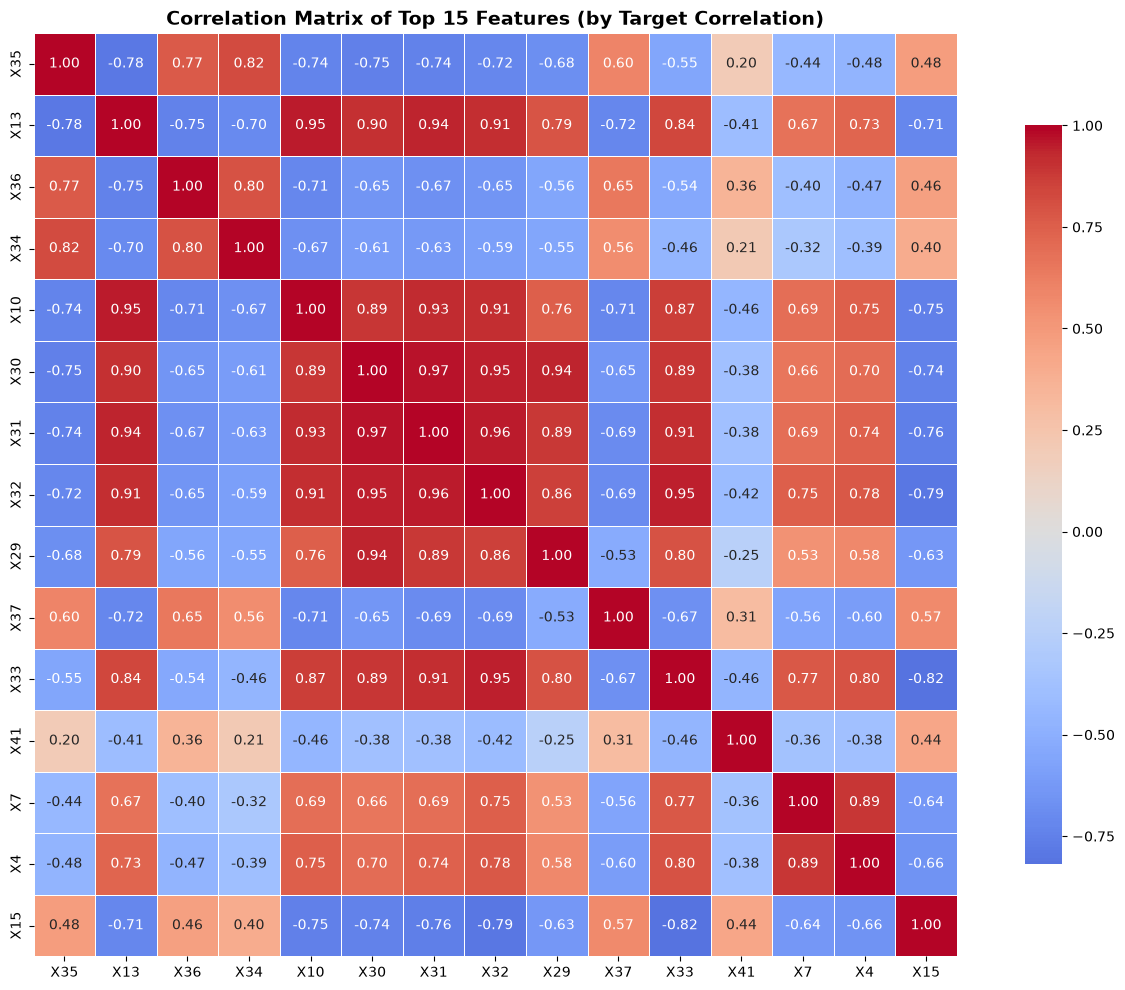


MULTICOLLINEARITY CHECK

Found 28 pairs of highly correlated features (> 0.8):
  X4 - X7: 0.890
  X4 - X9: 0.844
  X5 - X6: 0.868
  X5 - X7: 0.835
  X7 - X9: 0.814
  X8 - X9: 0.881
  X9 - X32: 0.801
  X9 - X33: 0.840
  X10 - X13: 0.951
  X10 - X30: 0.887


In [7]:
# Analyze correlations between features and target variable
# This helps identify which features are most predictive of defects

print("="*80)
print("EXPLORATORY DATA ANALYSIS - FEATURE CORRELATIONS")
print("="*80)

# Calculate correlation with target variable for each feature
correlations = X_train_filled.corrwith(y_train).sort_values(ascending=False)

print("\nTop 10 features most positively correlated with defects:")
print(correlations.head(10))

print("\nTop 10 features most negatively correlated with defects:")
print(correlations.tail(10))

# Visualize the correlation matrix for top features
plt.figure(figsize=(14, 10))

# Select top 15 features based on absolute correlation with target
top_features = correlations.abs().sort_values(ascending=False).head(15).index
corr_matrix = X_train_filled[top_features].corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Top 15 Features (by Target Correlation)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Check for highly correlated features (multicollinearity)
print("\n" + "="*80)
print("MULTICOLLINEARITY CHECK")
print("="*80)

# Find pairs of features with high correlation (> 0.8)
high_corr_pairs = []
corr_matrix_full = X_train_filled.corr()
for i in range(len(corr_matrix_full.columns)):
    for j in range(i+1, len(corr_matrix_full.columns)):
        if abs(corr_matrix_full.iloc[i, j]) > 0.8:
            high_corr_pairs.append((corr_matrix_full.columns[i], 
                                   corr_matrix_full.columns[j],
                                   corr_matrix_full.iloc[i, j]))

if len(high_corr_pairs) > 0:
    print(f"\nFound {len(high_corr_pairs)} pairs of highly correlated features (> 0.8):")
    for pair in high_corr_pairs[:10]:  # Show first 10 pairs
        print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("\nNo highly correlated features found.")

In [8]:
# Scale features to handle different units and magnitudes
# RobustScaler is preferred for industrial data with outliers

print("="*80)
print("FEATURE SCALING AND DATA SPLIT")
print("="*80)

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# Initialize RobustScaler
# RobustScaler uses median and IQR, making it robust to outliers
scaler = RobustScaler()

# Fit scaler on training data and transform both train and test
# Important: Fit only on training data to avoid data leakage
print("Fitting scaler on training data...")
X_train_scaled = scaler.fit_transform(X_train_filled)
X_test_scaled = scaler.transform(X_test_filled)

print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

# Check the scaling effect
print("\nBefore scaling (first 5 features, first row):")
print(X_train_filled.iloc[0, :5].values)
print("\nAfter scaling (first 5 features, first row):")
print(X_train_scaled[0, :5])

# Split into train and validation sets (80-20 split)
# Stratify ensures same class distribution in both sets
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)

print(f"\nTraining set size: {X_tr.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(pd.Series(y_tr).value_counts())
print(f"\nValidation set class distribution:")
print(pd.Series(y_val).value_counts())

# Verify stratification preserved class ratio
print(f"\nDefect percentage in training: {y_tr.mean() * 100:.2f}%")
print(f"Defect percentage in validation: {y_val.mean() * 100:.2f}%")

FEATURE SCALING AND DATA SPLIT
Fitting scaler on training data...

Scaled training data shape: (1352, 49)
Scaled test data shape: (339, 49)

Before scaling (first 5 features, first row):
[854.7871951  501.08886815 414.841484   710.58331607 662.07201327]

After scaling (first 5 features, first row):
[-2.62460134 -0.27502407 -0.69861962 -0.12818201  0.0210952 ]

Training set size: 1081 samples
Validation set size: 271 samples

Training set class distribution:
Y
0.0    1028
1.0      53
Name: count, dtype: int64

Validation set class distribution:
Y
0.0    258
1.0     13
Name: count, dtype: int64

Defect percentage in training: 4.90%
Defect percentage in validation: 4.80%


In [9]:
# Train multiple diverse models for ensemble learning
# Each model captures different patterns in the data

print("="*80)
print("MODEL TRAINING - INDIVIDUAL MODELS")
print("="*80)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Define models with class_weight='balanced' to handle imbalanced data
# This automatically gives more importance to minority class (defects)
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',  # Handles class imbalance
        max_iter=1000, 
        random_state=42,
        C=1.0  # Regularization strength
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,  # Number of trees
        max_depth=15,      # Maximum depth of each tree
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',  # Handles class imbalance
        random_state=42,
        n_jobs=-1  # Use all CPU cores
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,  # Step size for updates
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.8,  # Use 80% of data for each tree (stochastic)
        random_state=42
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    )
}

# Dictionary to store results
model_results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    
    # Train the model
    model.fit(X_tr, y_tr)
    
    # Make predictions on validation set
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    
    # Store results
    model_results[name] = {
        'model': model,
        'recall': recall,
        'precision': precision,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  Recall: {recall:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

# Display summary of all models
print("\n" + "="*80)
print("MODEL PERFORMANCE SUMMARY")
print("="*80)

summary_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Recall': [model_results[m]['recall'] for m in model_results],
    'Precision': [model_results[m]['precision'] for m in model_results],
    'F1-Score': [model_results[m]['f1'] for m in model_results],
    'ROC-AUC': [model_results[m]['roc_auc'] for m in model_results]
})
print(summary_df.to_string(index=False))

# Identify the best performing model
best_model_name = summary_df.loc[summary_df['F1-Score'].idxmax(), 'Model']
print(f"\nBest model based on F1-Score: {best_model_name}")

MODEL TRAINING - INDIVIDUAL MODELS

Training Logistic Regression...
  Recall: 0.6923
  Precision: 0.2308
  F1-Score: 0.3462
  ROC-AUC: 0.8921

Training Random Forest...
  Recall: 0.3846
  Precision: 0.3333
  F1-Score: 0.3571
  ROC-AUC: 0.8521

Training Gradient Boosting...
  Recall: 0.0769
  Precision: 1.0000
  F1-Score: 0.1429
  ROC-AUC: 0.8459

Training AdaBoost...
  Recall: 0.0769
  Precision: 0.2500
  F1-Score: 0.1176
  ROC-AUC: 0.8365

MODEL PERFORMANCE SUMMARY
              Model   Recall  Precision  F1-Score  ROC-AUC
Logistic Regression 0.692308   0.230769  0.346154 0.892069
      Random Forest 0.384615   0.333333  0.357143 0.852117
  Gradient Boosting 0.076923   1.000000  0.142857 0.845856
           AdaBoost 0.076923   0.250000  0.117647 0.836464

Best model based on F1-Score: Random Forest


In [10]:
# Optimize decision threshold for each model to improve recall
# Lowering threshold increases recall but may decrease precision

print("="*80)
print("THRESHOLD OPTIMIZATION FOR RECALL")
print("="*80)

# Function to find optimal threshold for each model
def find_optimal_threshold(model, X_val, y_val, target_recall=1.0):
    """
    Find threshold that achieves target recall with best precision
    """
    # Get predicted probabilities
    y_proba = model.predict_proba(X_val)[:, 1]
    
    # Try thresholds from 0.1 to 0.5
    thresholds = np.linspace(0.1, 0.5, 20)
    best_threshold = 0.5
    best_precision = 0
    best_recall = 0
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        recall = recall_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred) if recall > 0 else 0
        
        # We want high recall, but track best precision when recall is high
        if recall >= 0.95:  # Aim for 95%+ recall
            if precision > best_precision:
                best_precision = precision
                best_threshold = threshold
                best_recall = recall
    
    # If no threshold achieves 95% recall, take the one with highest recall
    if best_threshold == 0.5:
        best_recall = 0
        for threshold in thresholds:
            y_pred = (y_proba >= threshold).astype(int)
            recall = recall_score(y_val, y_pred)
            if recall > best_recall:
                best_recall = recall
                best_threshold = threshold
    
    return best_threshold, best_recall, best_precision

# Find optimal threshold for each model
print("Finding optimal thresholds...\n")
threshold_results = {}

for name, result in model_results.items():
    model = result['model']
    optimal_threshold, recall_at_threshold, precision_at_threshold = find_optimal_threshold(
        model, X_val, y_val
    )
    
    threshold_results[name] = {
        'threshold': optimal_threshold,
        'recall': recall_at_threshold,
        'precision': precision_at_threshold
    }
    
    print(f"{name}:")
    print(f"  Optimal threshold: {optimal_threshold:.3f}")
    print(f"  Recall at threshold: {recall_at_threshold:.4f}")
    print(f"  Precision at threshold: {precision_at_threshold:.4f}")

# Now apply these thresholds and get predictions
print("\n" + "="*80)
print("ENSEMBLE WITH OPTIMAL THRESHOLDS")
print("="*80)

# Create ensemble predictions using optimal thresholds
ensemble_proba = np.zeros(len(X_val))
for i, (name, result) in enumerate(model_results.items()):
    model = result['model']
    proba = model.predict_proba(X_val)[:, 1]
    # Apply model-specific threshold
    threshold = threshold_results[name]['threshold']
    pred_class = (proba >= threshold).astype(int)
    ensemble_proba += pred_class / len(model_results)

# Final ensemble predictions (majority vote)
ensemble_pred = (ensemble_proba >= 0.5).astype(int)

# Evaluate ensemble
ensemble_recall = recall_score(y_val, ensemble_pred)
ensemble_precision = precision_score(y_val, ensemble_pred)
ensemble_f1 = f1_score(y_val, ensemble_pred)

print(f"\nEnsemble Performance (Majority Vote):")
print(f"  Recall: {ensemble_recall:.4f}")
print(f"  Precision: {ensemble_precision:.4f}")
print(f"  F1-Score: {ensemble_f1:.4f}")

# Check if we meet the target
if ensemble_recall >= 0.95 and ensemble_precision >= 0.90:
    print("\n✓ TARGET MET: Recall >= 95% and Precision >= 90%")
else:
    print(f"\n⚠ Needs improvement: Recall={ensemble_recall:.4f}, Precision={ensemble_precision:.4f}")

# Try more aggressive ensemble approach
print("\n" + "="*80)
print("AGGRESSIVE ENSEMBLE (Max Recall)")
print("="*80)

# Use very low threshold to maximize recall
aggressive_threshold = 0.2
ensemble_agg_proba = np.zeros(len(X_val))
for name, result in model_results.items():
    model = result['model']
    proba = model.predict_proba(X_val)[:, 1]
    pred_class = (proba >= aggressive_threshold).astype(int)
    ensemble_agg_proba += pred_class / len(model_results)

ensemble_agg_pred = (ensemble_agg_proba >= 0.3).astype(int)  # Lower threshold

agg_recall = recall_score(y_val, ensemble_agg_pred)
agg_precision = precision_score(y_val, ensemble_agg_pred)

print(f"Ensemble with threshold=0.3:")
print(f"  Recall: {agg_recall:.4f}")
print(f"  Precision: {agg_precision:.4f}")
print(f"  Number of defects predicted: {ensemble_agg_pred.sum()} out of {len(y_val)}")

THRESHOLD OPTIMIZATION FOR RECALL
Finding optimal thresholds...

Logistic Regression:
  Optimal threshold: 0.142
  Recall at threshold: 1.0000
  Precision at threshold: 0.1368
Random Forest:
  Optimal threshold: 0.100
  Recall at threshold: 0.8462
  Precision at threshold: 0.0000
Gradient Boosting:
  Optimal threshold: 0.100
  Recall at threshold: 0.2308
  Precision at threshold: 0.0000
AdaBoost:
  Optimal threshold: 0.311
  Recall at threshold: 1.0000
  Precision at threshold: 0.0909

ENSEMBLE WITH OPTIMAL THRESHOLDS

Ensemble Performance (Majority Vote):
  Recall: 1.0000
  Precision: 0.1368
  F1-Score: 0.2407

⚠ Needs improvement: Recall=1.0000, Precision=0.1368

AGGRESSIVE ENSEMBLE (Max Recall)
Ensemble with threshold=0.3:
  Recall: 0.9231
  Precision: 0.1412
  Number of defects predicted: 85 out of 271
